In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [8]:

df = pd.read_csv("../data/cves.csv")
df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16953 entries, 0 to 16952
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cve_id         16953 non-null  str    
 1   published      16953 non-null  str    
 2   last_modified  16953 non-null  str    
 3   description    16953 non-null  str    
 4   cvss_score     15492 non-null  float64
 5   severity       16953 non-null  str    
 6   cvss_vector    15492 non-null  str    
 7   cwe            16953 non-null  str    
 8   has_patch      16953 non-null  bool   
dtypes: bool(1), float64(1), str(7)
memory usage: 1.1 MB


In [9]:
df["severity"].value_counts()

severity
MEDIUM      6847
HIGH        6236
CRITICAL    1726
UNKNOWN     1461
LOW          669
NONE          14
Name: count, dtype: int64

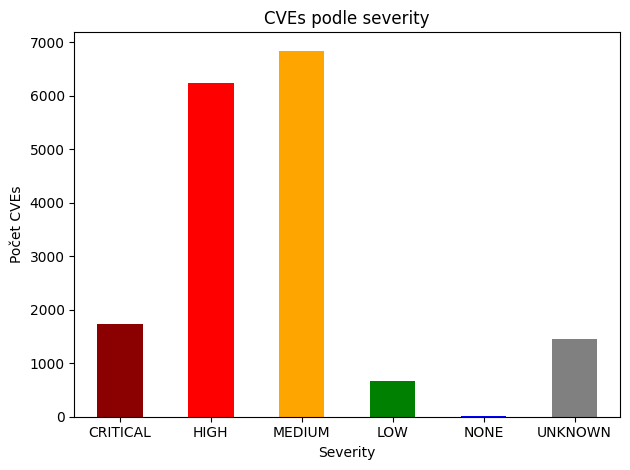

In [10]:
severity_order = ["CRITICAL", "HIGH", "MEDIUM", "LOW", "NONE", "UNKNOWN"]

df["severity"].value_counts()[severity_order].plot(
    kind="bar",
    color=["darkred", "red", "orange", "green", "blue", "gray"],
    title="CVEs podle severity"
)

plt.xlabel("Severity")
plt.ylabel("Počet CVEs")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
from importlib import reload
import src.cwe_client
reload(src.cwe_client)
from src.cwe_client import fetch_cwe_names

cwe_dict = fetch_cwe_names()
print(f"Načteno {len(cwe_dict)} CWE")
print(list(cwe_dict.items())[:5])

Načteno 969 CWE
[('CWE-1004', "Sensitive Cookie Without 'HttpOnly' Flag"), ('CWE-1007', 'Insufficient Visual Distinction of Homoglyphs Presented to User'), ('CWE-102', 'Struts: Duplicate Validation Forms'), ('CWE-1021', 'Improper Restriction of Rendered UI Layers or Frames'), ('CWE-1022', 'Use of Web Link to Untrusted Target with window.opener Access')]


In [20]:
df["cwe_name"] = df["cwe"].map(cwe_dict)
df[["cwe", "cwe_name"]].head(10)

,cwe,cwe_name
0,CWE-119,Improper Restriction of Operations within the ...
1,CWE-79,Improper Neutralization of Input During Web Pa...
2,CWE-1336,Improper Neutralization of Special Elements Us...
3,CWE-22,Improper Limitation of a Pathname to a Restric...
4,CWE-94,Improper Control of Generation of Code ('Code ...
5,CWE-404,Improper Resource Shutdown or Release
6,CWE-93,Improper Neutralization of CRLF Sequences ('CR...
7,CWE-74,Improper Neutralization of Special Elements in...
8,CWE-74,Improper Neutralization of Special Elements in...
9,CWE-74,Improper Neutralization of Special Elements in...


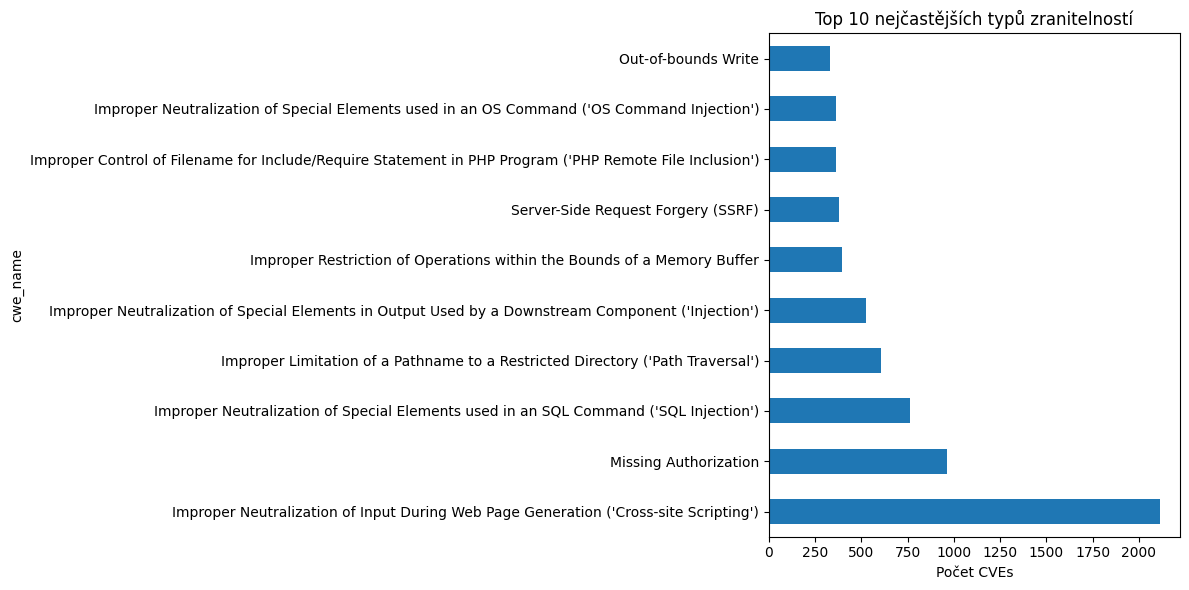

In [21]:
top_cwe = df["cwe_name"].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_cwe.plot(kind="barh")
plt.title("Top 10 nejčastějších typů zranitelností")
plt.xlabel("Počet CVEs")
plt.tight_layout()
plt.show()

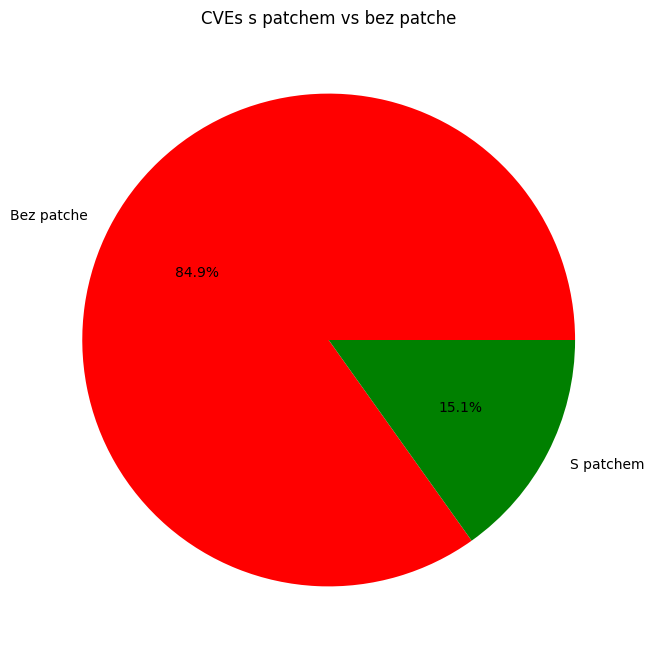

In [28]:
# ma nebo nema patch
patch_counts = df["has_patch"].value_counts()

plt.figure(figsize=(8, 8))
patch_counts.plot(
    kind="pie",
    labels=["Bez patche", "S patchem"],
    colors=["red", "green"],
    autopct="%1.1f%%"
)
plt.title("CVEs s patchem vs bez patche")
plt.ylabel("")
plt.show()


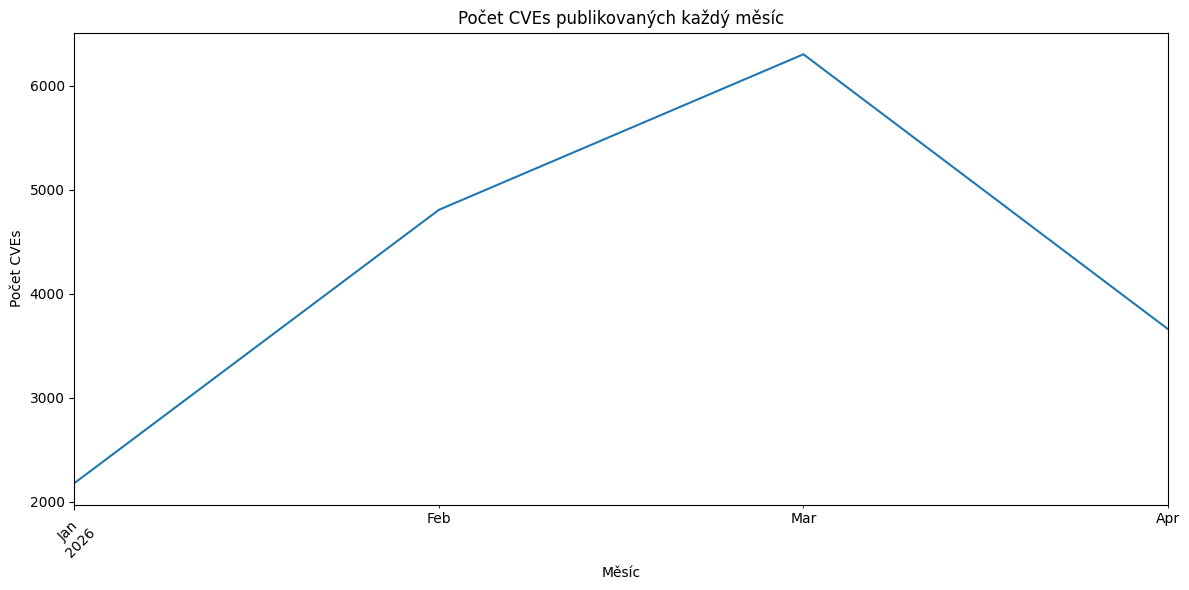

In [34]:
# prevedeme str na datetime
df["published_date"] = pd.to_datetime(df["published"])
df["published_date"].head()
df["month"] = df["published_date"].dt.to_period("M")
df["month"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
df["month"].value_counts().sort_index().plot()
plt.title("Počet CVEs publikovaných každý měsíc")  
plt.xlabel("Měsíc")
plt.ylabel("Počet CVEs")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

